# Paso 5 - Analisis final de metricas

Este notebook carga los resultados experimentales finales y genera tablas/graficos para inspeccionar cada metrica relevante del proyecto.

Incluye:

- comparacion global de modelos,
- comparacion en usuarios con historial corto,
- ranking por cada metrica,
- mejoras relativas del modelo propuesto,
- resultados del tuning,
- tradeoff entre relevancia, novedad, diversidad y coverage.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path('..').resolve().parent
OUTPUT_DIR = PROJECT_DIR / 'H3' / 'outputs'
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

## 1. Cargar resultados finales

In [2]:
overall = pd.read_csv(OUTPUT_DIR / 'final_metrics_summary_full.csv')
short = pd.read_csv(OUTPUT_DIR / 'final_metrics_short_history_full.csv')
tuning = pd.read_csv(OUTPUT_DIR / 'step2_tuning_results_sample_50000.csv')
tradeoffs = pd.read_csv(OUTPUT_DIR / 'step4_reranking_tradeoffs_sample_50000.csv')

metrics = [
    'precision@10',
    'recall@10',
    'ndcg@10',
    'novelty@10',
    'category_diversity@10',
    'catalog_coverage@10',
]
short_metrics = [
    'precision@10',
    'recall@10',
    'ndcg@10',
    'novelty@10',
    'category_diversity@10',
]

display(overall)
display(short)

,model,precision@10,recall@10,ndcg@10,novelty@10,category_diversity@10,catalog_coverage@10
0,Adaptive Hierarchical Hybrid (tuned),0.011413,0.114127,0.069032,13.596369,0.505077,0.495391
1,Fixed Hybrid Seq+Category,0.010945,0.109453,0.068414,13.165151,0.621789,0.494210
2,Sequential Transition,0.010251,0.102515,0.066455,13.245382,0.728481,0.516679
3,ItemKNN,0.007913,0.079134,0.043888,15.419379,0.741596,0.638723
4,Category Popularity,0.007632,0.076324,0.040498,13.500720,0.070065,0.078255
5,Most Popular,0.000219,0.002194,0.000931,10.198046,0.955455,0.000265
6,Random,0.000005,0.000052,0.000021,18.787670,0.995093,1.000000


,model,precision@10,recall@10,ndcg@10,novelty@10,category_diversity@10
0,Adaptive Hierarchical Hybrid (tuned),0.012759,0.127589,0.077486,13.524790,0.500161
1,Fixed Hybrid Seq+Category,0.012192,0.121917,0.076885,13.052526,0.638767
2,Sequential Transition,0.011390,0.113902,0.074636,13.095803,0.741881
3,ItemKNN,0.008757,0.087572,0.049372,15.090811,0.754958
4,Category Popularity,0.008523,0.085226,0.045413,13.454335,0.089281
5,Most Popular,0.000239,0.002391,0.001000,10.197705,0.955508
6,Random,0.000005,0.000053,0.000024,18.787995,0.995088


## 2. Comparacion global por metrica

El modelo principal fue seleccionado por Recall@10, usando nDCG@10 como criterio secundario. Novedad, diversidad y coverage se reportan como metricas complementarias para analizar tradeoffs.

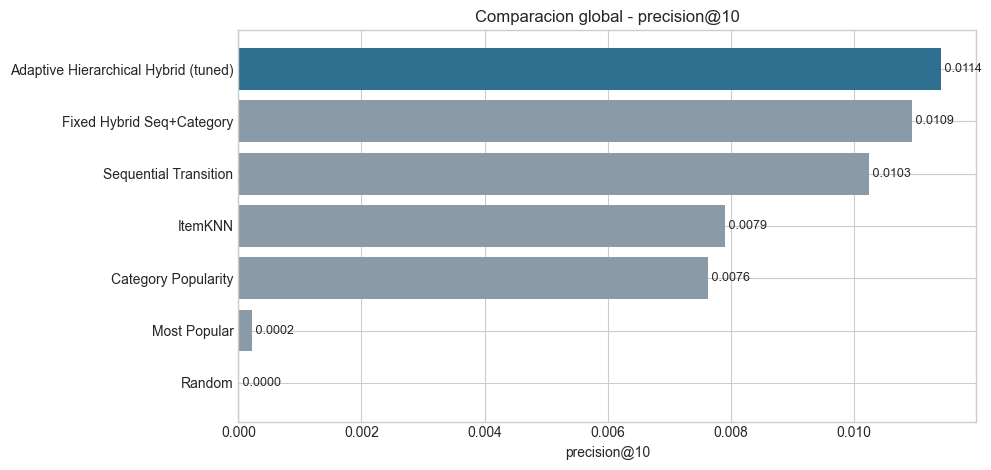

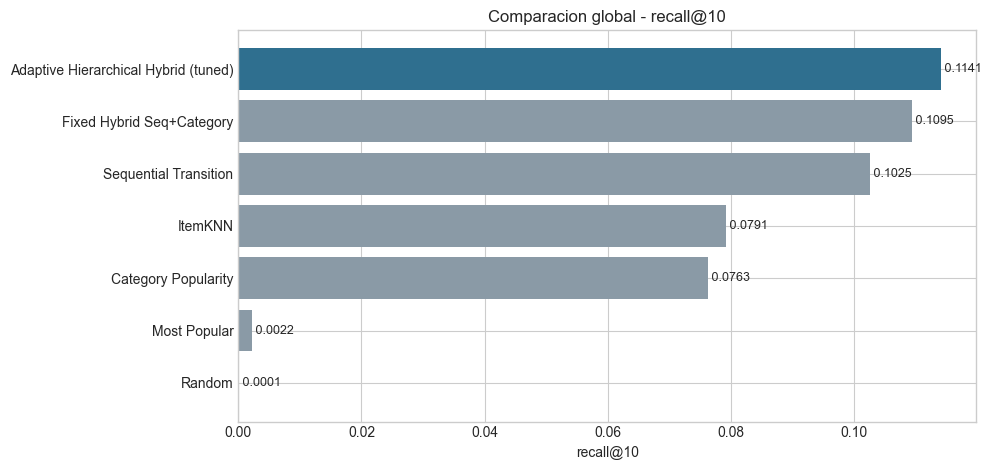

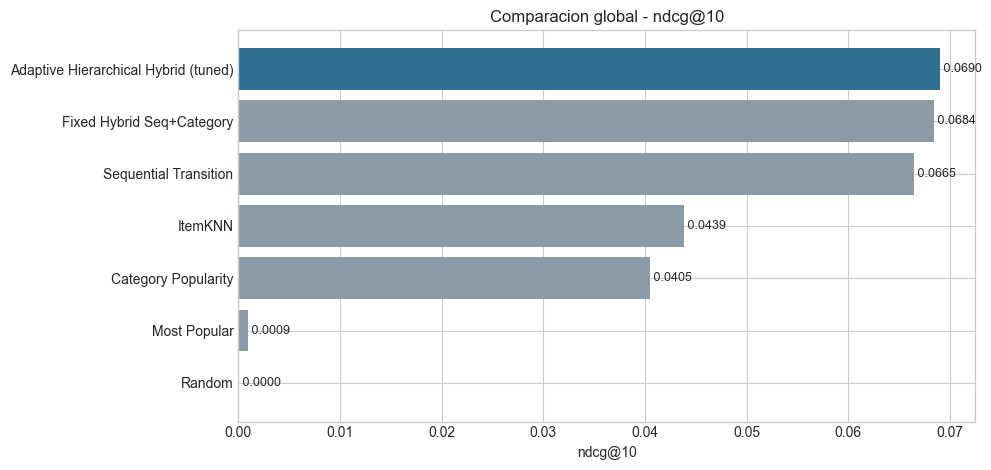

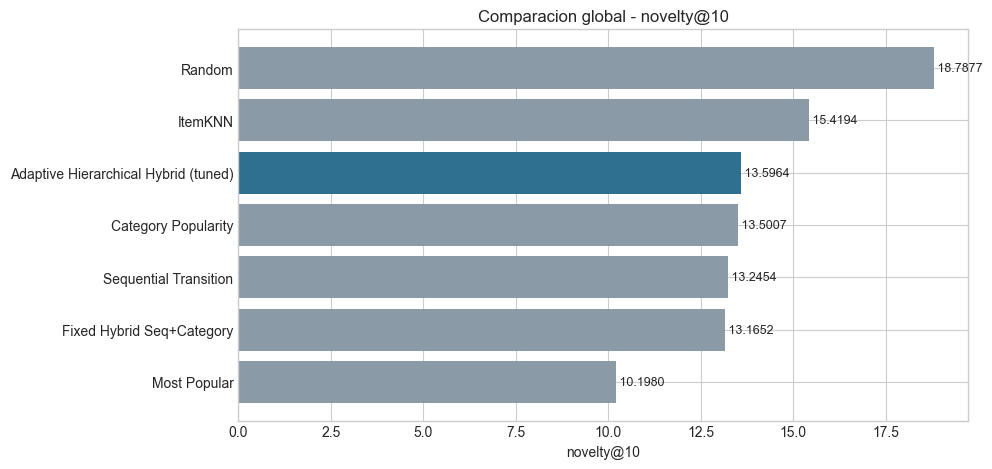

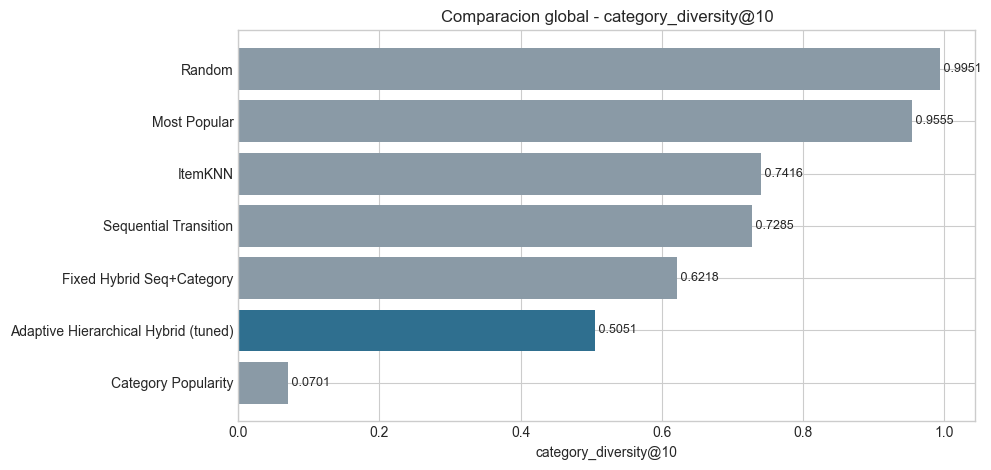

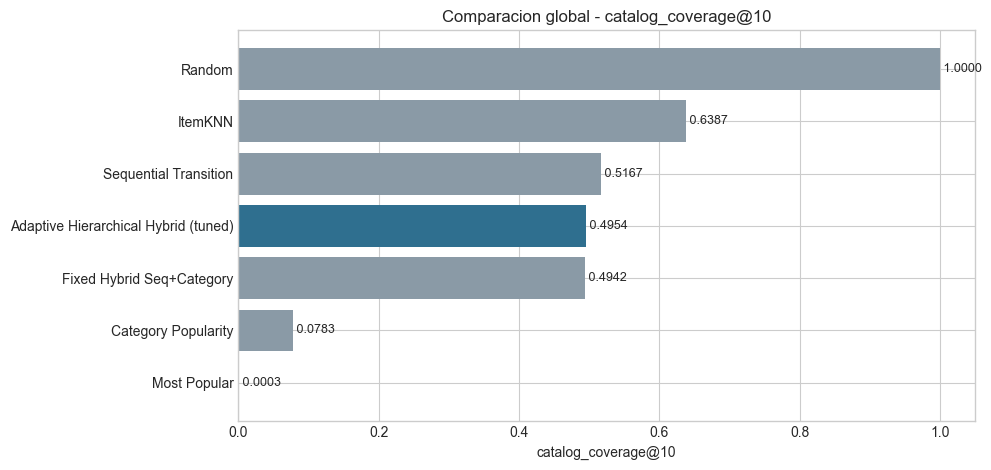

In [3]:
def plot_metric(df, metric, title, filename, ascending=False):
    plot_df = df.sort_values(metric, ascending=ascending).copy()
    fig, ax = plt.subplots(figsize=(10, 4.8))
    colors = ['#2f6f8f' if 'Adaptive Hierarchical' in model else '#8a9aa6' for model in plot_df['model']]
    ax.barh(plot_df['model'], plot_df[metric], color=colors)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel('')
    for i, value in enumerate(plot_df[metric]):
        ax.text(value, i, f' {value:.4f}', va='center', fontsize=9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=180, bbox_inches='tight')
    plt.show()


for metric in metrics:
    plot_metric(
        overall,
        metric,
        f'Comparacion global - {metric}',
        f'overall_{metric.replace("@", "_").replace("/", "_")}.png',
    )

## 3. Comparacion en usuarios con historial corto

Este grupo es central para el proyecto, porque representa usuarios con poca evidencia historica. La hipotesis es que categorias y jerarquia ayudan especialmente en este escenario.

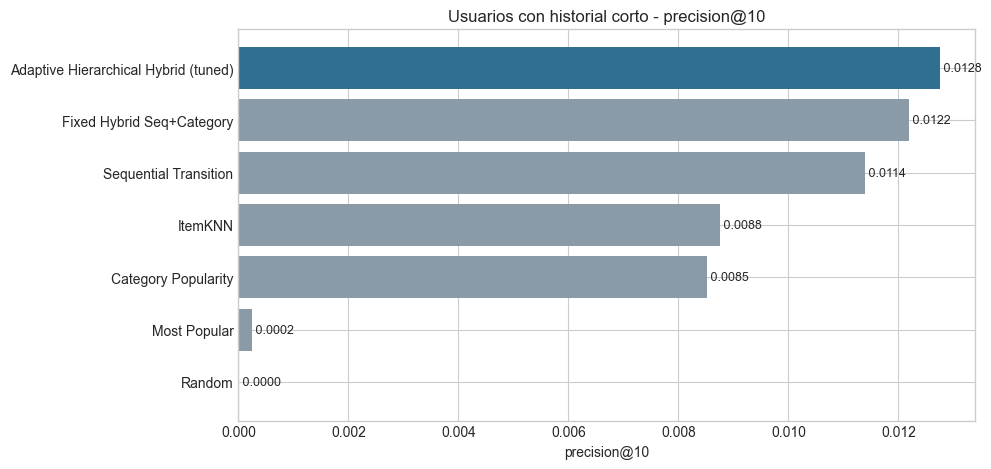

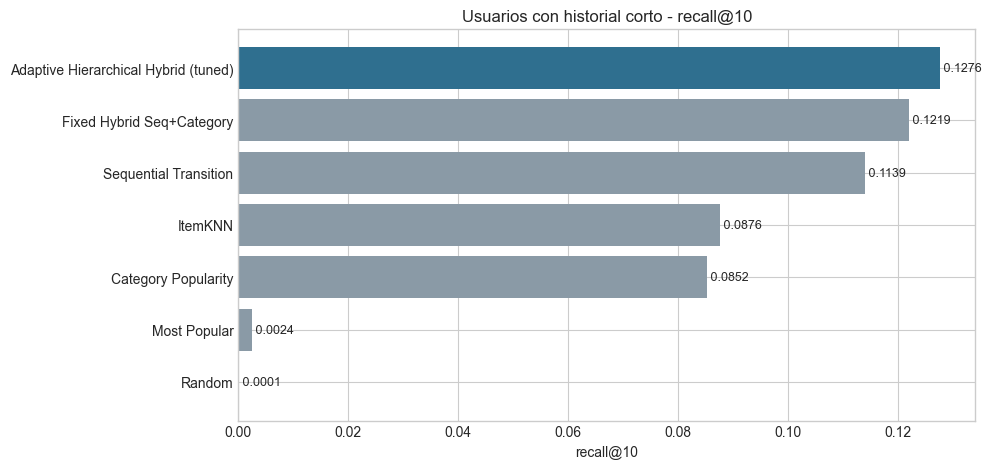

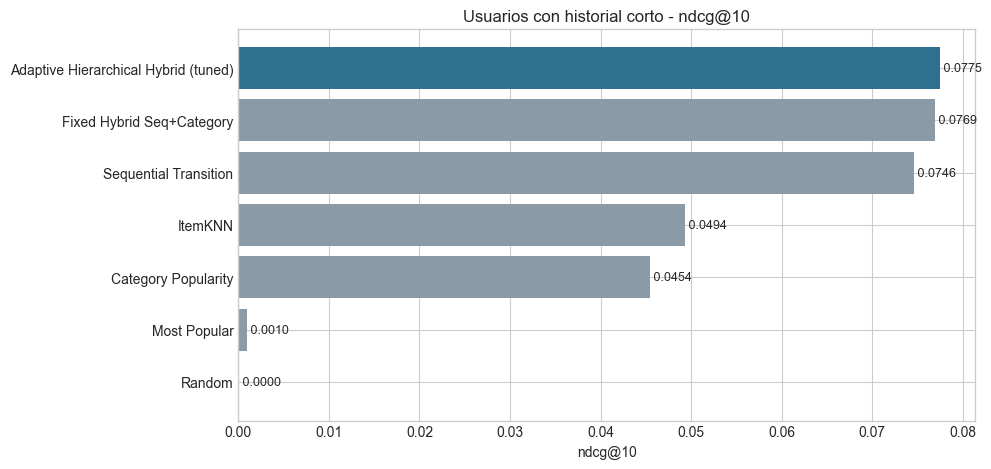

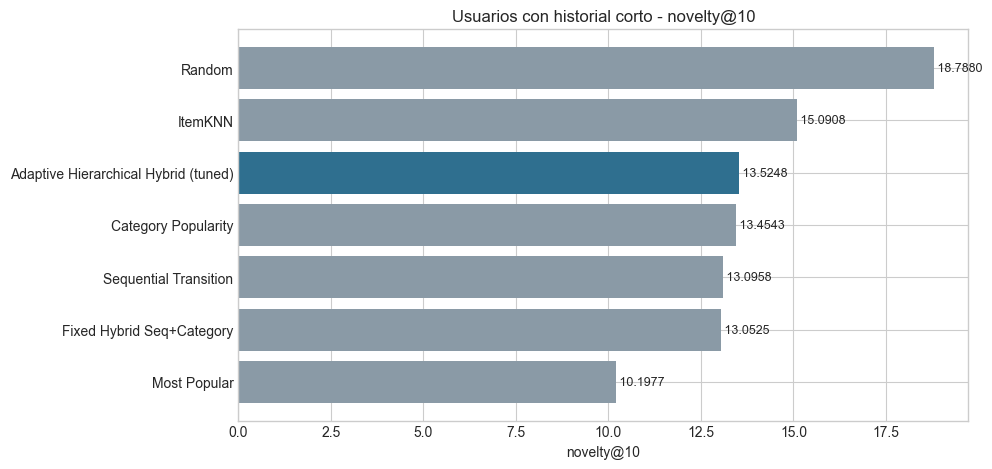

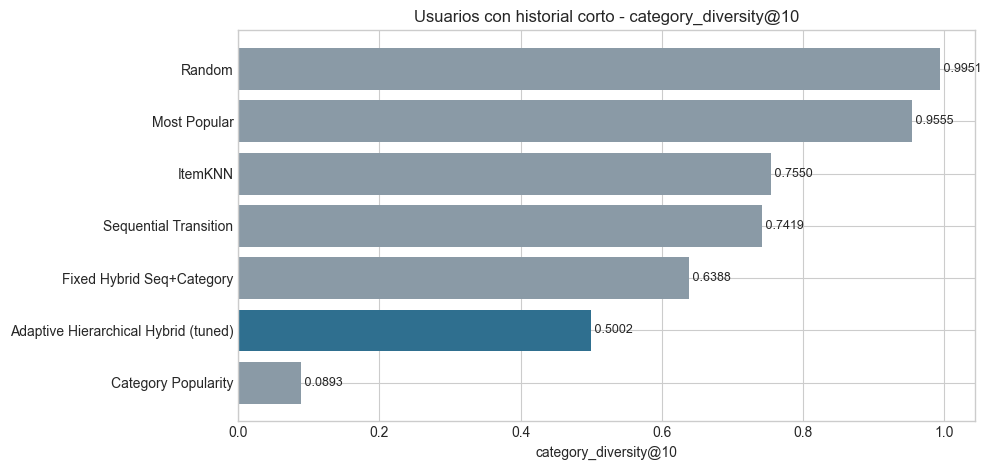

In [4]:
for metric in short_metrics:
    plot_metric(
        short,
        metric,
        f'Usuarios con historial corto - {metric}',
        f'short_{metric.replace("@", "_").replace("/", "_")}.png',
    )

## 4. Tabla de rankings por metrica

Esta tabla muestra que no todas las metricas favorecen al mismo modelo. Random e ItemKNN tienen mayor novedad/diversidad/cobertura, pero menor relevancia top-k. El modelo propuesto queda primero en Recall@10 y nDCG@10.

In [5]:
rank_rows = []
for metric in metrics:
    ranked = overall.sort_values(metric, ascending=False).reset_index(drop=True)
    for rank, row in ranked.iterrows():
        rank_rows.append({
            'metric': metric,
            'rank': rank + 1,
            'model': row['model'],
            'value': row[metric],
        })
metric_rankings = pd.DataFrame(rank_rows)
metric_rankings.to_csv(OUTPUT_DIR / 'step5_metric_rankings.csv', index=False)
display(metric_rankings.head(30))

,metric,rank,model,value
0,precision@10,1,Adaptive Hierarchical Hybrid (tuned),0.011413
1,precision@10,2,Fixed Hybrid Seq+Category,0.010945
2,precision@10,3,Sequential Transition,0.010251
3,precision@10,4,ItemKNN,0.007913
4,precision@10,5,Category Popularity,0.007632
5,precision@10,6,Most Popular,0.000219
6,precision@10,7,Random,0.000005
7,recall@10,1,Adaptive Hierarchical Hybrid (tuned),0.114127
8,recall@10,2,Fixed Hybrid Seq+Category,0.109453
9,recall@10,3,Sequential Transition,0.102515


## 5. Mejoras relativas del modelo propuesto

Comparamos el modelo propuesto contra los baselines mas relevantes: hibrido fijo, secuencial, ItemKNN y popularidad por categoria.

In [6]:
proposed_name = 'Adaptive Hierarchical Hybrid (tuned)'
proposed = overall.set_index('model').loc[proposed_name]
comparators = [
    'Fixed Hybrid Seq+Category',
    'Sequential Transition',
    'ItemKNN',
    'Category Popularity',
]

improvement_rows = []
for model in comparators:
    base = overall.set_index('model').loc[model]
    for metric in ['recall@10', 'ndcg@10', 'novelty@10', 'category_diversity@10', 'catalog_coverage@10']:
        improvement_rows.append({
            'baseline': model,
            'metric': metric,
            'baseline_value': base[metric],
            'proposed_value': proposed[metric],
            'relative_change': (proposed[metric] - base[metric]) / base[metric] if base[metric] != 0 else np.nan,
        })
improvements = pd.DataFrame(improvement_rows)
improvements.to_csv(OUTPUT_DIR / 'step5_relative_improvements.csv', index=False)
display(improvements)

,baseline,metric,baseline_value,proposed_value,relative_change
0,Fixed Hybrid Seq+Category,recall@10,0.109453,0.114127,0.042709
1,Fixed Hybrid Seq+Category,ndcg@10,0.068414,0.069032,0.009035
2,Fixed Hybrid Seq+Category,novelty@10,13.165151,13.596369,0.032754
3,Fixed Hybrid Seq+Category,category_diversity@10,0.621789,0.505077,-0.187704
4,Fixed Hybrid Seq+Category,catalog_coverage@10,0.494210,0.495391,0.002389
5,Sequential Transition,recall@10,0.102515,0.114127,0.113279
6,Sequential Transition,ndcg@10,0.066455,0.069032,0.038776
7,Sequential Transition,novelty@10,13.245382,13.596369,0.026499
8,Sequential Transition,category_diversity@10,0.728481,0.505077,-0.306671
9,Sequential Transition,catalog_coverage@10,0.516679,0.495391,-0.041201


## 6. Visualizacion Recall vs nDCG

Esta figura muestra la frontera de relevancia. El modelo propuesto se ubica arriba en Recall@10 y nDCG@10.

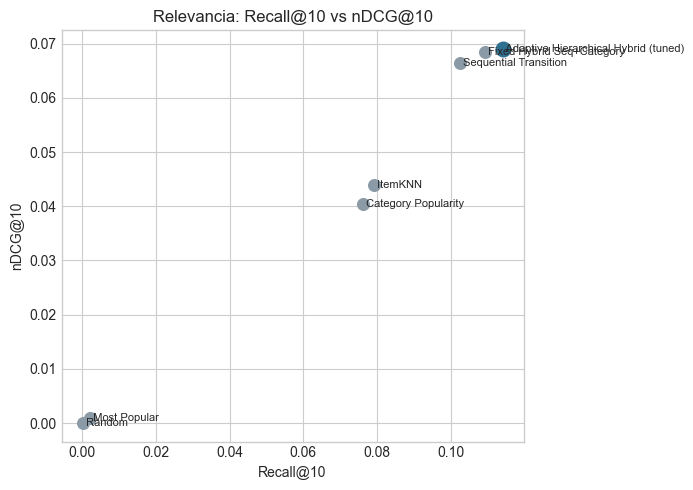

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for _, row in overall.iterrows():
    is_prop = row['model'] == proposed_name
    ax.scatter(row['recall@10'], row['ndcg@10'], s=110 if is_prop else 70, color='#2f6f8f' if is_prop else '#8a9aa6')
    ax.text(row['recall@10'], row['ndcg@10'], ' ' + row['model'], fontsize=8, va='center')
ax.set_xlabel('Recall@10')
ax.set_ylabel('nDCG@10')
ax.set_title('Relevancia: Recall@10 vs nDCG@10')
fig.tight_layout()
fig.savefig(FIG_DIR / 'recall_vs_ndcg.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Visualizacion de tradeoffs: relevancia vs novedad/diversidad/coverage

Estas figuras permiten explicar por que novelty/diversity no deben interpretarse solas. Random e ItemKNN pueden recomendar items mas diversos o novedosos, pero pierden bastante relevancia.

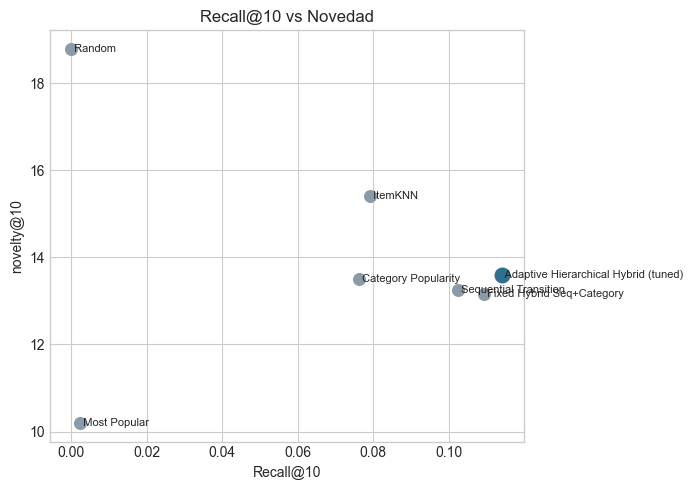

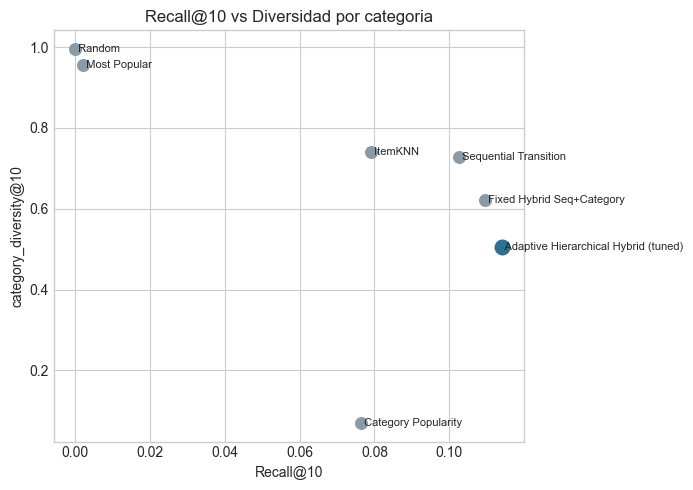

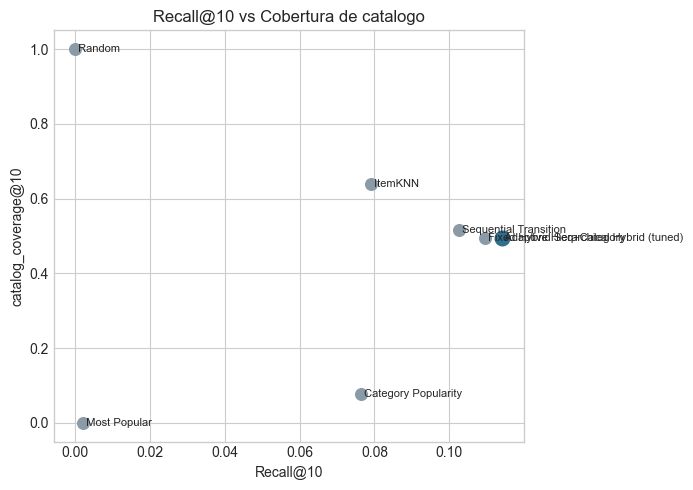

In [8]:
tradeoff_pairs = [
    ('novelty@10', 'Novedad'),
    ('category_diversity@10', 'Diversidad por categoria'),
    ('catalog_coverage@10', 'Cobertura de catalogo'),
]

for metric, label in tradeoff_pairs:
    fig, ax = plt.subplots(figsize=(7, 5))
    for _, row in overall.iterrows():
        is_prop = row['model'] == proposed_name
        ax.scatter(row['recall@10'], row[metric], s=110 if is_prop else 70, color='#2f6f8f' if is_prop else '#8a9aa6')
        ax.text(row['recall@10'], row[metric], ' ' + row['model'], fontsize=8, va='center')
    ax.set_xlabel('Recall@10')
    ax.set_ylabel(metric)
    ax.set_title(f'Recall@10 vs {label}')
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'recall_vs_{metric.replace("@", "_")}.png', dpi=180, bbox_inches='tight')
    plt.show()

## 8. Resultados del tuning

El tuning se realizo sobre 50.000 usuarios usando Recall@10 como criterio principal. Esta visualizacion muestra como cambian Recall@10 y nDCG@10 entre configuraciones.

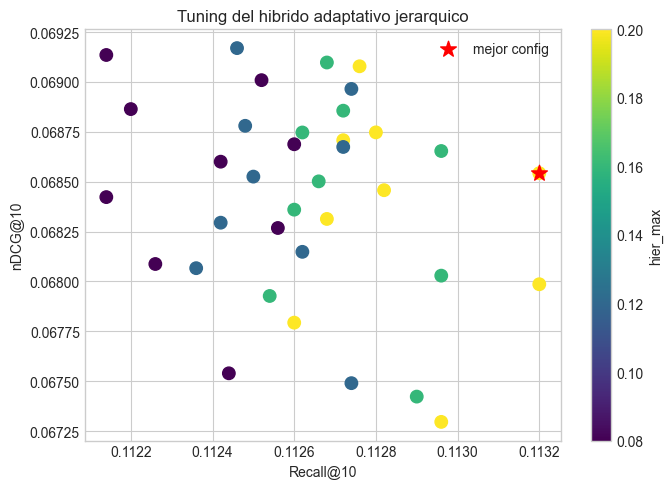

,name,seq_min,seq_span,cat_base,cat_drop,hier_max,hier_power,pop,transition_mix,use_hierarchy,precision@10,recall@10,ndcg@10,novelty@10,category_diversity@10,short_recall@10,short_ndcg@10,catalog_coverage@10
0,smin0.15_sspan0.7_h0.2,0.15,0.7,0.55,0.3,0.20,1.0,0.05,0.75,True,0.011320,0.11320,0.068543,13.598209,0.506618,0.125735,0.076627,0.299967
1,smin0.15_sspan0.6_h0.2,0.15,0.6,0.55,0.3,0.20,1.0,0.05,0.75,True,0.011320,0.11320,0.067986,13.584909,0.489448,0.125907,0.076048,0.295484
2,smin0.15_sspan0.7_h0.16,0.15,0.7,0.55,0.3,0.16,1.0,0.05,0.75,True,0.011296,0.11296,0.068654,13.580007,0.513529,0.125535,0.076810,0.300438
3,smin0.15_sspan0.6_h0.16,0.15,0.6,0.55,0.3,0.16,1.0,0.05,0.75,True,0.011296,0.11296,0.068029,13.562571,0.497613,0.125535,0.076098,0.295623
4,smin0.15_sspan0.5_h0.2,0.15,0.5,0.55,0.3,0.20,1.0,0.05,0.75,True,0.011296,0.11296,0.067296,13.558787,0.473344,0.125650,0.075259,0.289257
5,smin0.15_sspan0.5_h0.16,0.15,0.5,0.55,0.3,0.16,1.0,0.05,0.75,True,0.011290,0.11290,0.067423,13.540838,0.480558,0.125621,0.075414,0.289681
6,smin0.2_sspan0.6_h0.2,0.20,0.6,0.55,0.3,0.20,1.0,0.05,0.75,True,0.011282,0.11282,0.068457,13.553310,0.514346,0.125307,0.076578,0.298163
7,smin0.2_sspan0.7_h0.2,0.20,0.7,0.55,0.3,0.20,1.0,0.05,0.75,True,0.011280,0.11280,0.068747,13.570847,0.527615,0.125336,0.076930,0.302434
8,smin0.25_sspan0.7_h0.2,0.25,0.7,0.55,0.3,0.20,1.0,0.05,0.75,True,0.011276,0.11276,0.069078,13.570896,0.538251,0.125393,0.077382,0.304649
9,smin0.2_sspan0.7_h0.12,0.20,0.7,0.55,0.3,0.12,1.0,0.05,0.75,True,0.011274,0.11274,0.068965,13.549543,0.536161,0.125393,0.077252,0.303097


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(tuning['recall@10'], tuning['ndcg@10'], c=tuning['hier_max'], cmap='viridis', s=80)
best = tuning.sort_values(['recall@10', 'ndcg@10'], ascending=False).iloc[0]
ax.scatter(best['recall@10'], best['ndcg@10'], color='red', s=140, marker='*', label='mejor config')
ax.set_xlabel('Recall@10')
ax.set_ylabel('nDCG@10')
ax.set_title('Tuning del hibrido adaptativo jerarquico')
fig.colorbar(sc, ax=ax, label='hier_max')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'tuning_recall_ndcg.png', dpi=180, bbox_inches='tight')
plt.show()

display(tuning.sort_values(['recall@10', 'ndcg@10'], ascending=False).head(10))

## 9. Reranking para promover novedad/diversidad

Este experimento no cambia el modelo principal. Muestra que se puede promover novedad/diversidad mediante reranking, pero aparece un tradeoff con Recall@10/nDCG@10.

,model,precision@10,recall@10,ndcg@10,novelty@10,category_diversity@10,catalog_coverage@10,short_recall@10,short_ndcg@10
0,tuned_base,0.011320,0.11320,0.068543,13.598209,0.506618,0.299967,0.125735,0.076627
1,rerank_novelty_light,0.011320,0.11320,0.068543,13.598209,0.506618,0.299967,0.125735,0.076627
2,rerank_diversity_light,0.011320,0.11320,0.068543,13.598209,0.506618,0.299967,0.125735,0.076627
3,rerank_novelty_diversity_balanced,0.011320,0.11320,0.068543,13.598209,0.506618,0.299967,0.125735,0.076627
4,rerank_novelty_diversity_strong,0.011298,0.11298,0.068358,13.609523,0.510843,0.301651,0.125593,0.076451


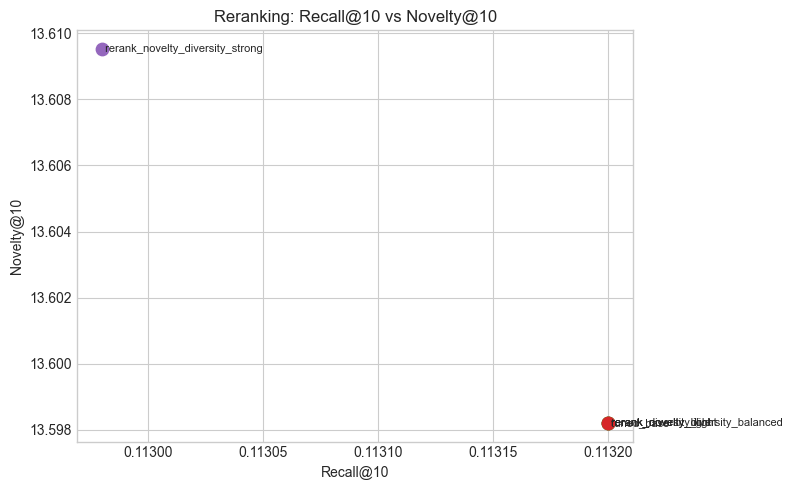

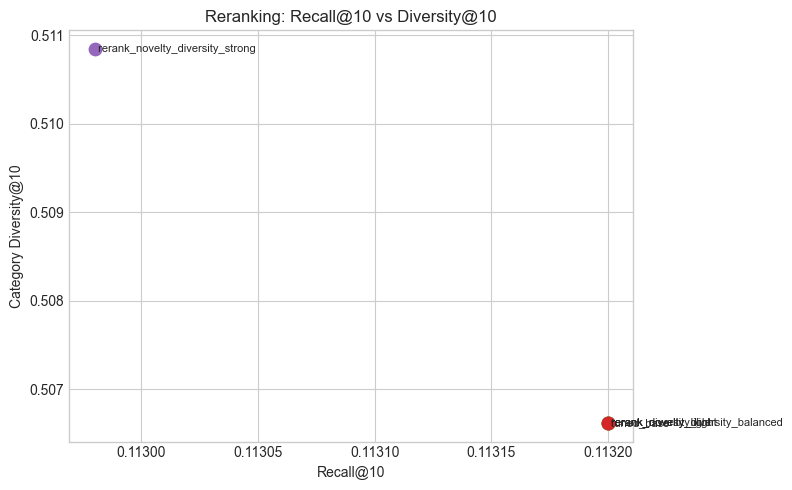

In [10]:
display(tradeoffs)

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in tradeoffs.iterrows():
    ax.scatter(row['recall@10'], row['novelty@10'], s=80)
    ax.text(row['recall@10'], row['novelty@10'], ' ' + row['model'], fontsize=8, va='center')
ax.set_xlabel('Recall@10')
ax.set_ylabel('Novelty@10')
ax.set_title('Reranking: Recall@10 vs Novelty@10')
fig.tight_layout()
fig.savefig(FIG_DIR / 'reranking_recall_vs_novelty.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in tradeoffs.iterrows():
    ax.scatter(row['recall@10'], row['category_diversity@10'], s=80)
    ax.text(row['recall@10'], row['category_diversity@10'], ' ' + row['model'], fontsize=8, va='center')
ax.set_xlabel('Recall@10')
ax.set_ylabel('Category Diversity@10')
ax.set_title('Reranking: Recall@10 vs Diversity@10')
fig.tight_layout()
fig.savefig(FIG_DIR / 'reranking_recall_vs_diversity.png', dpi=180, bbox_inches='tight')
plt.show()

## 10. Resumen experimental para usar en paper/poster

- El modelo propuesto obtiene el mejor Recall@10 y nDCG@10 global.\n- Tambien obtiene el mejor Recall@10 y nDCG@10 en usuarios con historial corto.\n- ItemKNN y Random muestran mas novedad/diversidad/cobertura, pero mucha menor relevancia top-k.\n- La jerarquia/adaptacion mejora al hibrido fijo en relevancia y novedad, con menor diversidad categorial interna.\n- El reranking muestra que novedad/diversidad pueden promoverse explicitamente, aunque con un costo leve en relevancia.